<a href="https://colab.research.google.com/github/deepto123/Neural-Networks-and-LLMs/blob/main/Loss_function_and_developing_a_character_level_biagram_model_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
names = open('/content/drive/MyDrive/Learning LLMs/names.txt', 'r').read().splitlines()

In [ ]:
names[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [ ]:
len(names)

32033

In [ ]:
print(min(len(name) for name in names))
print(max(len(name) for name in names))

2
15


In [ ]:
# basically zip is an iterator so we ch1 points to name[0] and ch2 at name[1] intially
# now when the list is exhausted and ietrator is pointing to null it doesnt return anything

biagram = {}

for name in names[:]:
  chs = ['<s>'] + list(name) + ['<e>']
  # print(chs)
  for ch1, ch2 in zip(chs, chs[1:]):
    b = (ch1,ch2)
    biagram[b] = biagram.get(b, 0) + 1

print(biagram)

{('<s>', 'e'): 1531, ('e', 'm'): 769, ('m', 'm'): 168, ('m', 'a'): 2590, ('a', '<e>'): 6640, ('<s>', 'o'): 394, ('o', 'l'): 619, ('l', 'i'): 2480, ('i', 'v'): 269, ('v', 'i'): 911, ('i', 'a'): 2445, ('<s>', 'a'): 4410, ('a', 'v'): 834, ('v', 'a'): 642, ('<s>', 'i'): 591, ('i', 's'): 1316, ('s', 'a'): 1201, ('a', 'b'): 541, ('b', 'e'): 655, ('e', 'l'): 3248, ('l', 'l'): 1345, ('l', 'a'): 2623, ('<s>', 's'): 2055, ('s', 'o'): 531, ('o', 'p'): 95, ('p', 'h'): 204, ('h', 'i'): 729, ('<s>', 'c'): 1542, ('c', 'h'): 664, ('h', 'a'): 2244, ('a', 'r'): 3264, ('r', 'l'): 413, ('l', 'o'): 692, ('o', 't'): 118, ('t', 't'): 374, ('t', 'e'): 716, ('e', '<e>'): 3983, ('<s>', 'm'): 2538, ('m', 'i'): 1256, ('a', 'm'): 1634, ('m', 'e'): 818, ('<s>', 'h'): 874, ('r', 'p'): 14, ('p', 'e'): 197, ('e', 'r'): 1958, ('r', '<e>'): 1377, ('e', 'v'): 463, ('v', 'e'): 568, ('l', 'y'): 1588, ('y', 'n'): 1826, ('n', '<e>'): 6763, ('b', 'i'): 217, ('i', 'g'): 428, ('g', 'a'): 330, ('a', 'i'): 1650, ('i', 'l'): 1345,

In [ ]:
sorted(biagram.items(), key = lambda kv: -kv[1])

[(('n', '<e>'), 6763),
 (('a', '<e>'), 6640),
 (('a', 'n'), 5438),
 (('<s>', 'a'), 4410),
 (('e', '<e>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<s>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<s>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<e>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<s>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<e>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<s>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<e>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<s>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<s>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<s>', 'l'), 1572),
 (('<s>', 'c'), 1542),
 (('<s>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [ ]:
import torch

In [ ]:
a = torch.zeros((3,5))
a

tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])

In [ ]:
a.dtype

torch.float32

In [ ]:
a[2][3] = 1
a

tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0.]])

In [ ]:
N = torch.zeros((27,27), dtype = torch.int32)

In [ ]:
chars = sorted(list(set(''.join(names))))
stoi = {ch:i+1 for i, ch in enumerate(chars)}
stoi['.'] = 0
print(stoi)

itos = {i:s for s,i in stoi.items()}
print(itos)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [ ]:
for name in names:
  chs = ['.'] + list(name) + ['.']
  # print(chs)
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    N[ix1, ix2] +=1 #equivalent to N[ix1][ix2]

type(N)

torch.Tensor

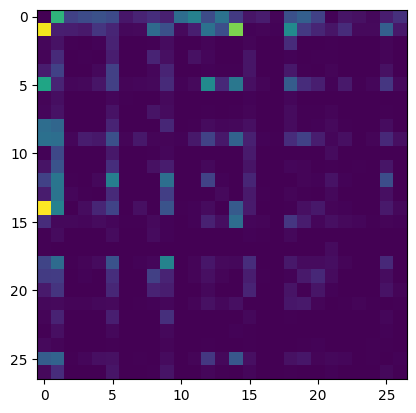

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.imshow(N)

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

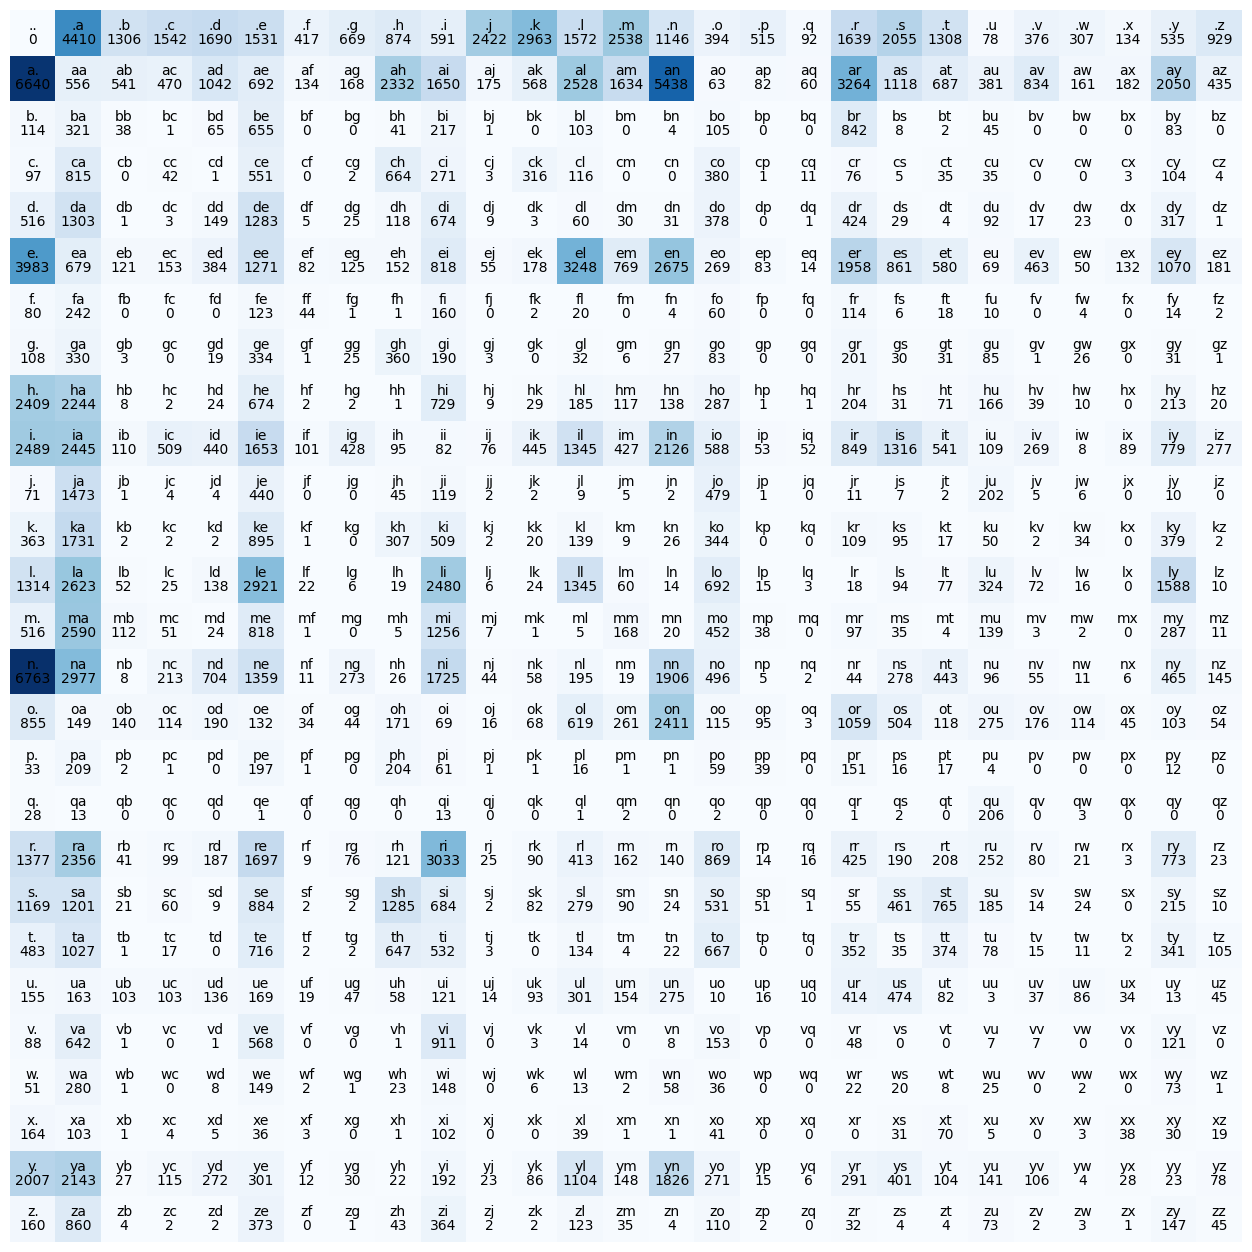

In [ ]:
# In Python's matplotlib, the reason you use plt.text(j, i, ...) instead of (i, j) comes down to a fundamental clash between matrix indexing and Cartesian coordinates.

# Here is exactly why it happens:

# 1. Matrix Indexing vs. Graph Coordinates
# The Loop (i and j): When you iterate through your 2D PyTorch tensor N using nested loops, i represents the row index (vertical axis, top to bottom) and j represents the column index (horizontal axis, left to right).

# The Plotting Function (plt.text): Matplotlib's plotting functions expect coordinates in standard Cartesian format: (x, y).

# x is the horizontal distance from the left.

# y is the vertical distance from the bottom (or top, in the case of images).

plt.figure (figsize= (16, 16))
plt.imshow (N, cmap = 'Blues')

for i in range(27):
  for j in range(27):
    chstr = itos[i] + itos[j]
    plt.text(j, i, chstr, ha = "center", va = "bottom", color = "black")
    plt.text(j, i, N[i,j].item(), ha = "center", va = "top", color = "black")
plt.axis('off')

In [ ]:
N[0]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [ ]:
p = N[0].float()
p = p/p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [ ]:
# we use it to generate values corresponsing to 0,1,2(range =3).
# Diving by sum just gives away their probabilities
g = torch.Generator().manual_seed(282828283)
p = torch.rand(3, generator= g)
p = p / p.sum()
p

tensor([0.0298, 0.2902, 0.6801])

In [ ]:
# now we use these probabilities to generate numbers from 0 to 1
torch.multinomial(p, num_samples=30, replacement =True, generator =g)

tensor([2, 1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 1, 2, 2, 1, 2, 1, 2, 1, 1,
        2, 1, 2, 1, 2, 2])

In [ ]:
tensor_array = (N+1).float()
tensor_array_sum_horizontal = torch.sum(input = tensor_array, dim = 0, keepdim=True, dtype=torch.float32)
tensor_array_sum_vertical= torch.sum(input = tensor_array, dim = 1, keepdim=True, dtype=torch.float32)


probabilities_horizontal = tensor_array/tensor_array_sum_horizontal
probabilites_vertical = tensor_array/tensor_array_sum_vertical


if (probabilities_horizontal == probabilites_vertical).all():
    print("Equal")
else:
    print('Unequal')

# print(tensor_array.shape)
print(tensor_array_sum_vertical)

# print(tensor_array_sum)


Unequal
tensor([[32060.],
        [33912.],
        [ 2672.],
        [ 3559.],
        [ 5523.],
        [20450.],
        [  932.],
        [ 1954.],
        [ 7643.],
        [17728.],
        [ 2927.],
        [ 5067.],
        [13985.],
        [ 6669.],
        [18354.],
        [ 7961.],
        [ 1053.],
        [  299.],
        [12727.],
        [ 8133.],
        [ 5597.],
        [ 3162.],
        [ 2600.],
        [  956.],
        [  724.],
        [ 9803.],
        [ 2425.]])


In [ ]:
# 1. Flatten both sum tensors to simple 1D arrays of size [27]
# (Using .view(-1) strips away the mismatched [1, 27] and [27, 1] dimensions)
horiz_sums = tensor_array_sum_horizontal.view(-1)
vert_sums = tensor_array_sum_vertical.view(-1)

# 2. Find the indices where they do NOT match
# We use ~torch.isclose to safely handle floating-point math
mismatch_indices = torch.where(~torch.isclose(horiz_sums, vert_sums))[0]

if len(mismatch_indices) == 0:
    print("Perfect match across all characters!")
else:
    print(f"Found differences in {len(mismatch_indices)} out of 27 positions:\n")
    print(f"{'Char':<6} | {'Horizontal Sum (Start)':<22} | {'Vertical Sum (End)':<20} | {'Difference':<10}")
    print("-" * 70)

    for idx in mismatch_indices:
        char = itos[idx.item()]
        h_val = horiz_sums[idx].item()
        v_val = vert_sums[idx].item()
        diff = abs(h_val - v_val)

        print(f"'{char}'__{idx.item():<2} | {h_val:<22.4f} | {v_val:<20.4f} | {diff:.4f}")

Perfect match across all characters!


(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

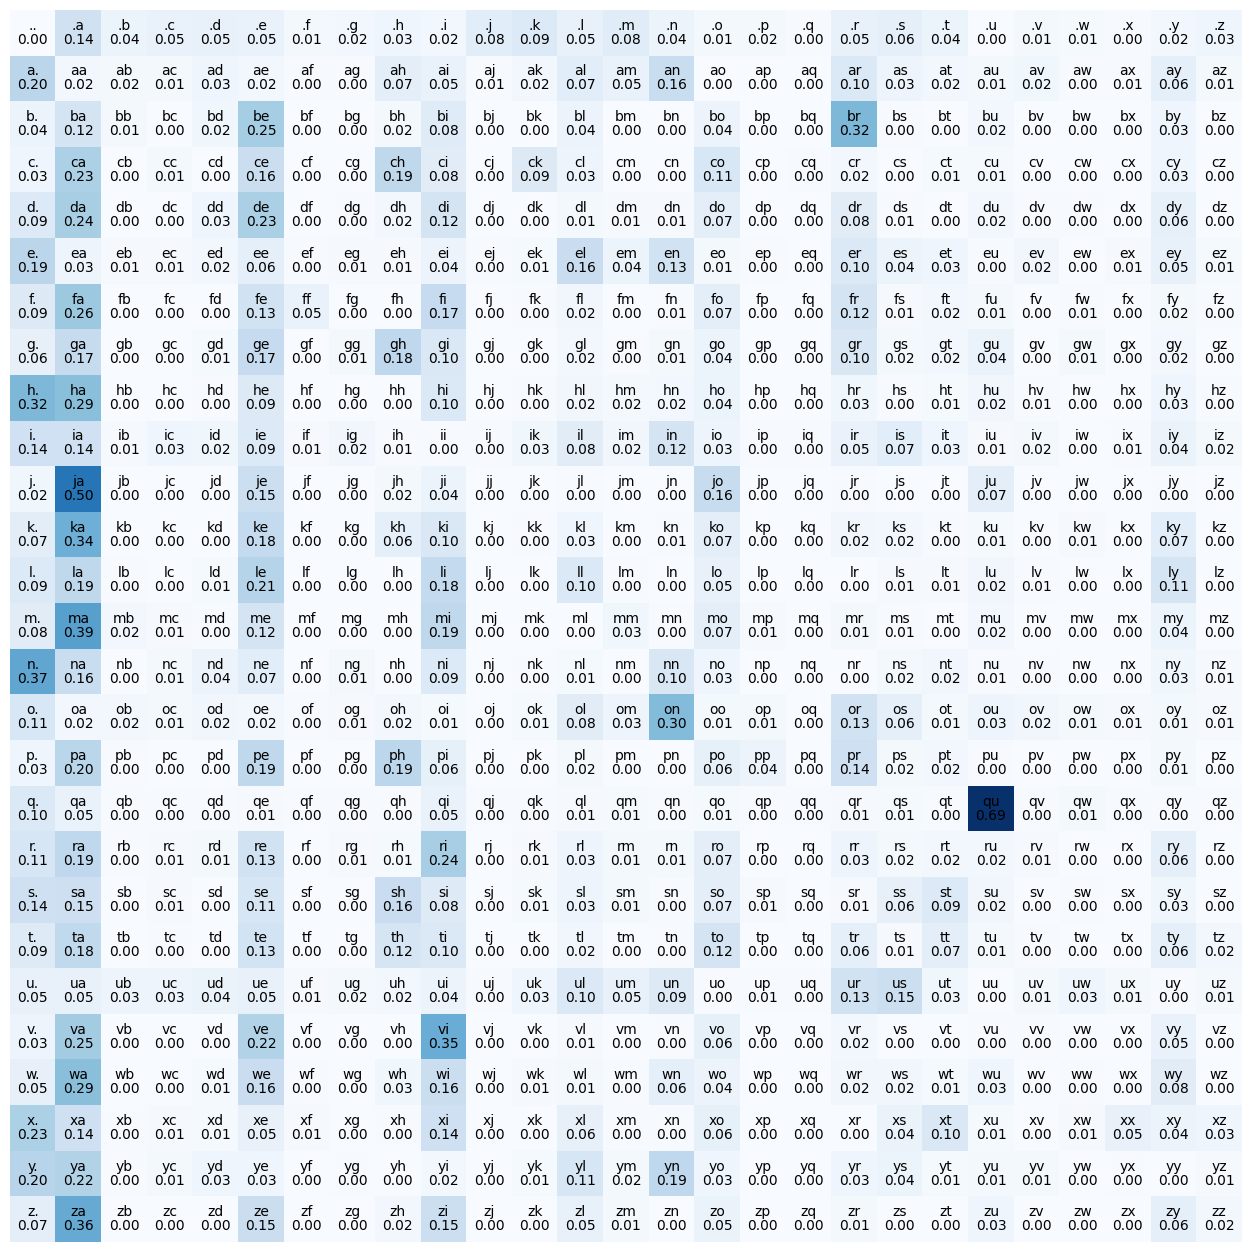

In [ ]:
plt.figure (figsize= (16, 16))
plt.imshow (probabilites_vertical, cmap = 'Blues')

for i in range(27):
  for j in range(27):
    chstr = itos[i] + itos[j]
    plt.text(j, i, chstr, ha = "center", va = "bottom", color = "black")
    plt.text(j, i, f"{probabilites_vertical[i,j].item():.2f}", ha = "center", va = "top", color = "black")
plt.axis('off')

In [ ]:
probabilites_vertical[1].sum()

tensor(1.)

In [ ]:
#  lets generate the starting character after .
id = torch.multinomial(probabilites_vertical, num_samples=1, replacement =True, generator =g)
print(id)

tensor([[ 2],
        [17],
        [18],
        [ 0],
        [ 9],
        [13],
        [ 9],
        [ 5],
        [ 0],
        [20],
        [ 1],
        [ 5],
        [ 9],
        [ 5],
        [20],
        [19],
        [ 5],
        [21],
        [ 9],
        [ 1],
        [ 8],
        [20],
        [ 5],
        [ 8],
        [ 5],
        [21],
        [ 1]])


In [ ]:
# # Now lets start generating characters in a loop

# # but before that we need to learn how torhc.sum() works. So if we see the above image
# # we basically want to add along the column i.e. 0 dimenion

# # next is keepDimension, so basically when we are dividing a [27,27] tensor by [27,1] tensor,
# # it reduces to a [27,1] tensor if we preverse the dimension, else it will reduce to [27] dimension 1d array
g = torch.Generator().manual_seed(2147483647)

for i in range(50):
  result = ''
  ch = '.'
  # generate a new character
  while(True):
    index = stoi[ch]
    # p = N[:,index].float()
    # p = p/p.sum()

    id = torch.multinomial(probabilites_vertical[index], num_samples=1, replacement =True, generator =g).item()
    # print(probabilities_horizontal[:, index].sum())
    ch = itos[id]
    result += ch
    if(ch == '.'):
      break

  print(result)


cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.
ka.
emimmsade.
enkaviyny.
ftlspihinivenvorhlasu.
dsor.
br.
jol.
pen.
aisan.
ja.
feniee.
zem.
deru.
firit.
gaikajahahbevare.
kiysthelenaririenah.
keen.
x.
al.
kal.
thavazeeromysos.
laitenimieegariseriyen.
k.
illeleldole.
meenisammigama.
mmin.
asharin.
alcalar.
jayn.
asaz.
selanely.
chay.
rana.
ai.
yviamisashougen.
l.
beyncaro.
allan.
annutetoradrilia.
rddeman.


In [ ]:
p = N[:, 0].float()
print(p)
p = p/p.sum()
print(p)

print(probabilites_vertical[:,0])

tensor([   0., 6640.,  114.,   97.,  516., 3983.,   80.,  108., 2409., 2489.,
          71.,  363., 1314.,  516., 6763.,  855.,   33.,   28., 1377., 1169.,
         483.,  155.,   88.,   51.,  164., 2007.,  160.])
tensor([0.0000, 0.2073, 0.0036, 0.0030, 0.0161, 0.1243, 0.0025, 0.0034, 0.0752,
        0.0777, 0.0022, 0.0113, 0.0410, 0.0161, 0.2111, 0.0267, 0.0010, 0.0009,
        0.0430, 0.0365, 0.0151, 0.0048, 0.0027, 0.0016, 0.0051, 0.0627, 0.0050])
tensor([3.1192e-05, 1.9583e-01, 4.3039e-02, 2.7536e-02, 9.3609e-02, 1.9482e-01,
        8.6910e-02, 5.5783e-02, 3.1532e-01, 1.4046e-01, 2.4599e-02, 7.1837e-02,
        9.4029e-02, 7.7523e-02, 3.6853e-01, 1.0752e-01, 3.2289e-02, 9.6990e-02,
        1.0827e-01, 1.4386e-01, 8.6475e-02, 4.9336e-02, 3.4231e-02, 5.4393e-02,
        2.2790e-01, 2.0484e-01, 6.6392e-02])


## Learn broadcasting rules


## Designing the loss function


In [ ]:
log_likelihood = 0.0
count =0
for name in names[:3]:
  chs = ['.'] + list(name) + ['.']
  # print(chs)
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = probabilites_vertical[ix1,ix2]
    logprob = torch.log(prob)
    print(f'{ch1}{ch2}: {prob:.4f} {logprob:4f}')
    log_likelihood += logprob
    count +=1

nll = -log_likelihood
print("log_likelihood:" + str(log_likelihood.item()))
print(f'{nll=}')
print(f'loss: {nll/count}')

.e: 0.0478 -3.041035
em: 0.0377 -3.279348
mm: 0.0253 -3.675327
ma: 0.3885 -0.945426
a.: 0.1958 -1.630506
.o: 0.0123 -4.396479
ol: 0.0779 -2.552590
li: 0.1774 -1.729324
iv: 0.0152 -4.184479
vi: 0.3508 -1.047627
ia: 0.1380 -1.980691
a.: 0.1958 -1.630506
.a: 0.1376 -1.983508
av: 0.0246 -3.704093
va: 0.2473 -1.397122
a.: 0.1958 -1.630506
log_likelihood:-38.80856704711914
nll=tensor(38.8086)
loss: 2.4255354404449463


In [ ]:
# Maximum likehood estimation

# Likelihood is the product of all the probabilities. But multiplying all the probabilities will result ina very small decimal number. So instead we woork with log likelihood
# Negative log likelihood is basically the negative of ll, so it will always be psitive

# so now loss is low, means that ll is closer to 0, or the probabilities assigned by training set is high



In [ ]:
# GOAL: maximize the likelihod of he data wrt model params(statistical modelling)
# equivalent to maximizing the log likelihood
# equivalent to minimizing the negative log likelihood
# equivalent to minimizing the average negative log likelihood

In [ ]:
log_likelihood = 0.0
count =0
for name in ["deeptojq"]:
  chs = ['.'] + list(name) + ['.']
  # print(chs)
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = probabilites_vertical[ix1,ix2]
    logprob = torch.log(prob)
    print(f'{ch1}{ch2}: {prob:.4f} {logprob:4f}')
    log_likelihood += logprob
    count +=1

nll = -log_likelihood
print("log_likelihood:" + str(log_likelihood.item()))
print(f'{nll=}')
print(f'loss: {nll/count}')

.d: 0.0527 -2.942289
de: 0.2325 -1.458941
ee: 0.0622 -2.777392
ep: 0.0041 -5.494921
pt: 0.0171 -4.069026
to: 0.1193 -2.125698
oj: 0.0021 -6.149096
jq: 0.0003 -7.981733
q.: 0.0970 -2.333148
log_likelihood:-35.33224868774414
nll=tensor(35.3322)
loss: 3.9258053302764893


In [ ]:
# Now we see since jq has prob of 0, our result becomes infinite because log(0) = inf.
# So what we do basically is do model smootening bu adding a ranodm constant number to all the N matrix
# Now if we add a larger number we will have a smoother model and if we add a smaller number, we will have a peaked model

## Neural nets approach

The probabisltic model is not scalable for a sequence, if we try to see some charater and then guess the next characters as it scales exponentially. So the alternative approach is to write down a character and guess the next ones (neural networks)

In [ ]:
#  create a training set of biagrams.

xs, ys = [], []

for name in names[:1]:
  chs = ['.'] + list(name) + ['.']
  # print(chs)
  for ch1, ch2 in zip(chs, chs[1:]):
    print(ch1, ch2)
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

. e
e m
m m
m a
a .


In [ ]:
xs

tensor([ 0,  5, 13, 13,  1])

In [ ]:
ys

tensor([ 5, 13, 13,  1,  0])

In [ ]:
# Now lets think about how we feed the input to our neural net. its not feasible
#  to directly pass tensor array above as the neural net wont be able to make much sense of it and process it. Itos(character) * probailty gives nothing much logical
#  So we use one hat encoding where we take a vector of 27 corresponding to a single charcter. Now for that index in that word we do a one hot encoding.
# This helps us to macth out probabiltiy vector with the next predicted output

In [ ]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=27).float()
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

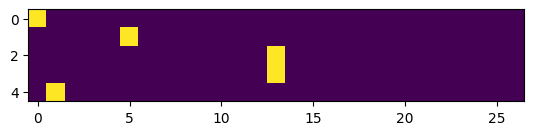

In [ ]:
plt.imshow(xenc)

In [ ]:
W = torch.randn((27,1))
# this will generate random numbers based on normal distribution
print(W)

tensor([[-0.8493],
        [-1.6442],
        [ 0.1511],
        [ 0.2132],
        [ 0.1814],
        [ 1.5122],
        [ 0.5314],
        [ 0.6449],
        [-2.5650],
        [-0.1493],
        [ 0.8633],
        [ 0.3210],
        [ 0.0492],
        [-1.8435],
        [-0.3410],
        [ 1.0346],
        [ 1.4055],
        [ 0.3229],
        [ 1.2890],
        [-1.9740],
        [-0.8185],
        [-0.0950],
        [ 0.9077],
        [ 0.6576],
        [ 0.0778],
        [ 0.5564],
        [-0.8125]])


In [ ]:
xenc @ W

# this represents the matrix multiplication of a single neuron.There are 5 inputs vectors of size 27 each,
# each vector is multiplied with the probability of the character that is one-hoted and that returns the
# next character. However we know that there are 27 foloowing probabilities for a single character and thats why we need a 27*27 mmatrix

tensor([[-0.8493],
        [ 1.5122],
        [-1.8435],
        [-1.8435],
        [-1.6442]])

In [ ]:
W = torch.randn((27,27))
print(W)

# now we have 27 neurons
# here ethere are 27*27 weights, so when we do
# [5,27] * [27 *27] = [5, 27]
# for each character, we get a a probability vector of 27 that has allthe 27 possibilities.

tensor([[ 0.3877, -0.6725, -0.5568,  0.2175,  1.8753, -0.8734,  0.7597,  0.7389,
          1.0084,  1.3281, -0.0659,  3.3000,  1.2433,  0.9060,  2.4297, -0.7635,
          0.0540,  0.9011, -0.3107,  0.5314,  0.8101, -0.1934, -1.6027, -0.8094,
         -0.4703, -1.5321, -0.8781],
        [ 1.4438, -1.0488, -2.5199, -1.9773,  0.6543, -0.2170,  0.3187, -0.7226,
          0.0053,  0.7296,  0.7820,  0.6617,  2.2011, -0.0926, -0.6795, -0.5798,
         -0.2283, -1.0774,  0.4597, -0.3274,  0.0305, -0.1464,  0.8716,  0.2503,
          0.3066, -0.2628,  0.0974],
        [-1.5935,  1.6516,  1.1138,  0.5217,  1.9503,  0.8397,  0.8781,  0.4546,
          1.5138, -1.0909,  2.5835, -2.1340, -2.1051, -0.8323,  0.3095,  1.2512,
          0.3611, -0.2260, -0.5813, -0.2094,  0.4338,  0.9695, -0.7392, -0.1593,
          1.4540, -1.0887, -0.8934],
        [-0.3420,  0.3835,  1.6888, -1.6559,  0.4640, -0.5441,  2.8061,  1.3943,
          0.3265,  2.2615,  0.2429, -1.7056,  0.2922, -0.9393,  0.3044,  0.4967

In [ ]:
xenc @ W

tensor([[ 0.3877, -0.6725, -0.5568,  0.2175,  1.8753, -0.8734,  0.7597,  0.7389,
          1.0084,  1.3281, -0.0659,  3.3000,  1.2433,  0.9060,  2.4297, -0.7635,
          0.0540,  0.9011, -0.3107,  0.5314,  0.8101, -0.1934, -1.6027, -0.8094,
         -0.4703, -1.5321, -0.8781],
        [-2.3584, -1.7001,  0.0100,  0.9417, -1.2646,  0.8594, -0.5672,  0.2784,
          0.0492,  0.4965, -0.1581,  1.7740, -0.6464,  0.1361,  1.9192, -0.3498,
          0.9872, -0.8821,  0.4455,  1.6755, -1.1569, -2.1640,  0.0634,  1.0264,
         -0.4410,  0.7206, -0.2028],
        [ 0.0958, -0.7888,  0.2109,  1.0944,  0.2185,  0.7788,  1.5441, -0.2770,
         -0.2731,  1.5326,  0.2042, -0.0304, -0.2283,  0.0756,  1.6461,  0.7107,
         -0.9511, -0.8733, -2.6792,  2.1453, -0.8770,  1.7615, -0.0909,  1.5735,
          3.1482,  0.3215, -0.3502],
        [ 0.0958, -0.7888,  0.2109,  1.0944,  0.2185,  0.7788,  1.5441, -0.2770,
         -0.2731,  1.5326,  0.2042, -0.0304, -0.2283,  0.0756,  1.6461,  0.7107

In [ ]:
# (5,27) @ (27, 27) -> (5, 27)

(xenc@W)[3, 13] ## gives the firing rate of neuron 13, given input 3

tensor(0.0756)

In [ ]:
# Now we need to work with positive numbers as probabilities can never be negative.
# So we exponentitae the weights to get positive numbers

logits = xenc @ W ## log-counts
counts = logits.exp() ## equivalent to the N matrix
print(counts)

tensor([[ 1.4736,  0.5104,  0.5731,  1.2430,  6.5227,  0.4175,  2.1376,  2.0937,
          2.7413,  3.7739,  0.9362, 27.1124,  3.4671,  2.4745, 11.3559,  0.4660,
          1.0555,  2.4622,  0.7329,  1.7013,  2.2481,  0.8242,  0.2013,  0.4451,
          0.6248,  0.2161,  0.4156],
        [ 0.0946,  0.1827,  1.0101,  2.5644,  0.2823,  2.3618,  0.5671,  1.3211,
          1.0504,  1.6430,  0.8538,  5.8943,  0.5239,  1.1458,  6.8157,  0.7048,
          2.6836,  0.4139,  1.5612,  5.3416,  0.3145,  0.1149,  1.0655,  2.7910,
          0.6434,  2.0556,  0.8164],
        [ 1.1006,  0.4544,  1.2348,  2.9875,  1.2442,  2.1789,  4.6839,  0.7580,
          0.7610,  4.6302,  1.2266,  0.9701,  0.7959,  1.0785,  5.1866,  2.0354,
          0.3863,  0.4176,  0.0686,  8.5448,  0.4160,  5.8211,  0.9131,  4.8237,
         23.2945,  1.3792,  0.7045],
        [ 1.1006,  0.4544,  1.2348,  2.9875,  1.2442,  2.1789,  4.6839,  0.7580,
          0.7610,  4.6302,  1.2266,  0.9701,  0.7959,  1.0785,  5.1866,  2.0354

In [ ]:
counts.sum(1, keepdims = True)

tensor([[78.2261],
        [44.8172],
        [78.0960],
        [78.0960],
        [39.8535]])

In [ ]:
probs = counts / counts.sum(1, keepdims = True)

In [ ]:
print(probs)

tensor([[0.0188, 0.0065, 0.0073, 0.0159, 0.0834, 0.0053, 0.0273, 0.0268, 0.0350,
         0.0482, 0.0120, 0.3466, 0.0443, 0.0316, 0.1452, 0.0060, 0.0135, 0.0315,
         0.0094, 0.0217, 0.0287, 0.0105, 0.0026, 0.0057, 0.0080, 0.0028, 0.0053],
        [0.0021, 0.0041, 0.0225, 0.0572, 0.0063, 0.0527, 0.0127, 0.0295, 0.0234,
         0.0367, 0.0190, 0.1315, 0.0117, 0.0256, 0.1521, 0.0157, 0.0599, 0.0092,
         0.0348, 0.1192, 0.0070, 0.0026, 0.0238, 0.0623, 0.0144, 0.0459, 0.0182],
        [0.0141, 0.0058, 0.0158, 0.0383, 0.0159, 0.0279, 0.0600, 0.0097, 0.0097,
         0.0593, 0.0157, 0.0124, 0.0102, 0.0138, 0.0664, 0.0261, 0.0049, 0.0053,
         0.0009, 0.1094, 0.0053, 0.0745, 0.0117, 0.0618, 0.2983, 0.0177, 0.0090],
        [0.0141, 0.0058, 0.0158, 0.0383, 0.0159, 0.0279, 0.0600, 0.0097, 0.0097,
         0.0593, 0.0157, 0.0124, 0.0102, 0.0138, 0.0664, 0.0261, 0.0049, 0.0053,
         0.0009, 0.1094, 0.0053, 0.0745, 0.0117, 0.0618, 0.2983, 0.0177, 0.0090],
        [0.1063, 0.0088,

In [ ]:
probs[0].sum()

tensor(1.)

In [ ]:
# counts = logits.exp()
# probs = counts / counts.sum(1, keepdims = True)

# This is called the softmax function

In [ ]:
# Now lets see how this works

print(xs)
print(ys)

tensor([ 0,  5, 13, 13,  1])
tensor([ 5, 13, 13,  1,  0])


In [ ]:
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g)

In [ ]:
xenc = F.one_hot(xs, num_classes=27).float()
logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(1, keepdims=True)

In [ ]:
nlls = torch.zeros(5)
for i in range(len(xs)):
  input_label = xs[i].item()
  output_label = ys[i].item()
  print(f'input_label=', input_label)
  print(f'output_label=', output_label)

  p = probs[i, output_label]
  print(f'probability assigned to output label:', p.item())

  nll = -torch.log(p)
  print(f'negative log likelihood', nll.item())

  nlls[i] = nll

print("average negative log likelihood" ,nlls.mean().item())

input_label= 0
output_label= 5
probability assigned to output label: 0.01228625513613224
negative log likelihood 4.399273872375488
input_label= 5
output_label= 13
probability assigned to output label: 0.018050700426101685
negative log likelihood 4.014570713043213
input_label= 13
output_label= 13
probability assigned to output label: 0.026691533625125885
negative log likelihood 3.623408794403076
input_label= 13
output_label= 1
probability assigned to output label: 0.07367686182260513
negative log likelihood 2.6080665588378906
input_label= 1
output_label= 0
probability assigned to output label: 0.014977526850998402
negative log likelihood 4.201204299926758
average negative log likelihood 3.7693049907684326


In [ ]:
# Now lets see how this works

print(xs)
print(ys)

tensor([ 0,  5, 13, 13,  1])
tensor([ 5, 13, 13,  1,  0])


In [ ]:
# randomly initialise 27 neyrons weights, each neuiron receives 27 inputs
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

In [ ]:
# forward pass
xenc = F.one_hot(xs, num_classes=27).float()
logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(1, keepdims=True)
loss = - probs[torch.arange(5), ys].log().mean()

In [ ]:
#  now we are interetsted in

probs[0, 5], probs[1, 13], probs[2, 13], probs [3, 1], probs [4, 0]

(tensor(0.0123, grad_fn=<SelectBackward0>),
 tensor(0.0181, grad_fn=<SelectBackward0>),
 tensor(0.0267, grad_fn=<SelectBackward0>),
 tensor(0.0737, grad_fn=<SelectBackward0>),
 tensor(0.0150, grad_fn=<SelectBackward0>))

In [ ]:
print(loss.item())

3.7693049907684326


In [ ]:
# backward pass

W.grad = None
loss.backward()

In [ ]:
# update the weights

W.data += -0.1* W.grad

In [ ]:
# The goal is to decrease the negative log likelihood
# randomly initialise 27 neurons weights, each neuiron receives 27 inputs

g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

for k in range(1000):
  # forward pass
  xenc = F.one_hot(xs, num_classes=27).float()
  logits = xenc @ W
  counts = logits.exp()
  probs = counts / counts.sum(1, keepdims=True)
  loss = - probs[torch.arange(5), ys].log().mean()
  print(loss.item())

  # backward pass
  W.grad = None
  loss.backward()

  # update the weights
  W.data += -0.1* W.grad



3.7693049907684326
3.7492127418518066
3.7291626930236816
3.7091541290283203
3.6891887187957764
3.6692662239074707
3.6493873596191406
3.629552125930786
3.6097614765167236
3.5900158882141113
3.5703155994415283
3.5506606101989746
3.5310521125793457
3.5114905834198
3.491975784301758
3.4725089073181152
3.453089952468872
3.4337196350097656
3.414397716522217
3.3951258659362793
3.375903367996216
3.356731414794922
3.3376102447509766
3.318540096282959
3.2995219230651855
3.2805557250976562
3.26164174079895
3.242781162261963
3.2239737510681152
3.2052199840545654
3.18652081489563
3.1678762435913086
3.1492867469787598
3.1307530403137207
3.1122748851776123
3.09385347366333
3.075488567352295
3.0571811199188232
3.0389316082000732
3.0207395553588867
3.0026066303253174
2.984531879425049
2.9665169715881348
2.948561191558838
2.930665969848633
2.9128310680389404
2.895056962966919
2.8773443698883057
2.8596930503845215
2.842103958129883
2.8245773315429688
2.8071131706237793
2.789712429046631
2.772374868392944

In [ ]:
# The goal is to decrease the negative log likelihood
# randomly initialise 27 neyrons weights, each neuiron receives 27 inputs

g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

# prepare the input and output sample
#  create a training set of biagrams.

xs, ys = [], []

for name in names[:]:
  chs = ['.'] + list(name) + ['.']
  # print(chs)
  for ch1, ch2 in zip(chs, chs[1:]):
    # print(ch1, ch2)
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

for k in range(1000):
  # forward pass
  xenc = F.one_hot(xs, num_classes=27).float()
  logits = xenc @ W
  counts = logits.exp()
  probs = counts / counts.sum(1, keepdims=True)

  loss = - probs[torch.arange(len(xs)), ys].log().mean()
  print(loss.item())

  # backward pass
  W.grad = None
  loss.backward()

  # update the weights
  W.data += -50.0* W.grad



3.758953809738159
3.371100425720215
3.1540427207946777
3.020373582839966
2.927711009979248
2.8604023456573486
2.8097288608551025
2.7701022624969482
2.7380728721618652
2.711496591567993
2.6890032291412354
2.6696884632110596
2.65293025970459
2.638277769088745
2.6253879070281982
2.613990545272827
2.60386323928833
2.5948219299316406
2.5867116451263428
2.5794036388397217
2.572789192199707
2.5667762756347656
2.5612878799438477
2.5562586784362793
2.551633596420288
2.547365665435791
2.543415069580078
2.5397486686706543
2.536336660385132
2.5331544876098633
2.5301804542541504
2.5273969173431396
2.5247862339019775
2.522334337234497
2.520028829574585
2.517857789993286
2.515810966491699
2.513878345489502
2.512052059173584
2.5103237628936768
2.5086872577667236
2.5071349143981934
2.5056614875793457
2.5042612552642822
2.5029289722442627
2.5016608238220215
2.5004520416259766
2.4992988109588623
2.498197317123413
2.4971446990966797
2.4961376190185547
2.495173692703247
2.4942493438720703
2.493363380432129

KeyboardInterrupt: 

In [ ]:
probs.shape

In [ ]:
#  finally, sample from the nerual net

g = torch.Generator().manual_seed(2147483647)

for i in range(5):

  out = []
  ix = 0

  while True:
    xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
    logits = xenc @ W
    counts = logits.exp()
    p = counts / counts.sum(1, keepdims=True)
    # print(p)
    ix = (torch.multinomial(p, num_samples=1, replacement=True, generator=g).item())
    out.append(itos[ix])
    if ix ==0:
      break

  print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.


(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

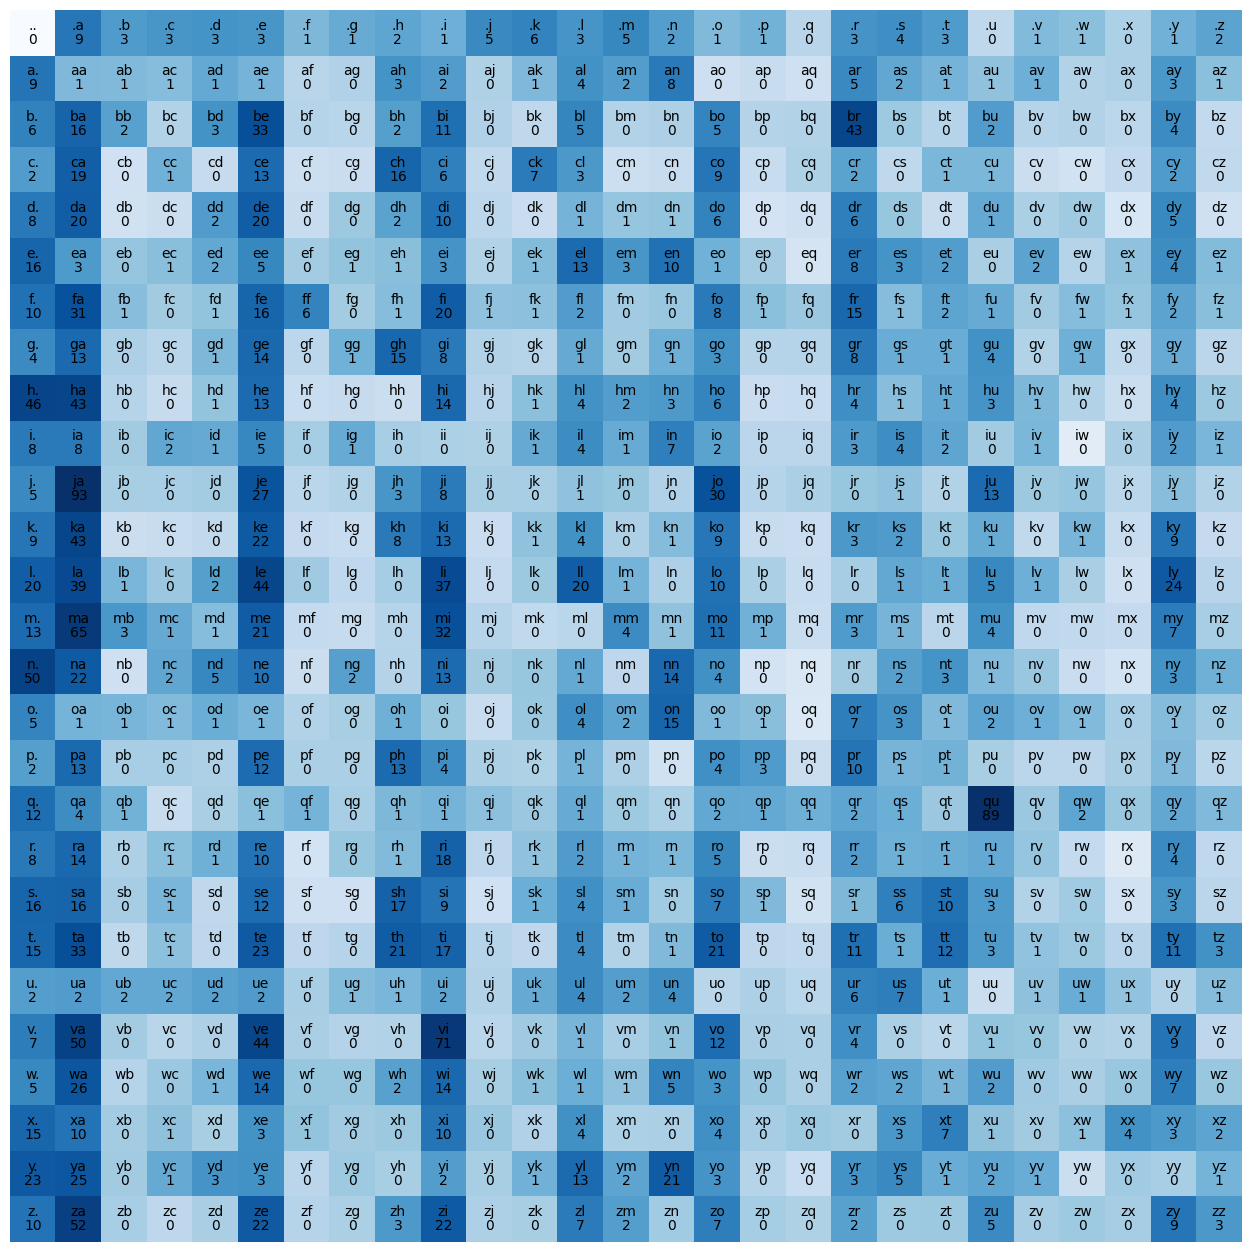

In [ ]:
plt.figure (figsize= (16, 16))
plt.imshow (W.data, cmap = 'Blues')

for i in range(27):
  for j in range(27):
    chstr = itos[i] + itos[j]
    plt.text(j, i, chstr, ha = "center", va = "bottom", color = "black")
    plt.text(j, i, f"{W[i,j].exp().item():.0f}", ha = "center", va = "top", color = "black")
plt.axis('off')

## Regularisation

As we learnt in the earlier, sometimes to make the model smooth and discard 0 probabilities(logx != inf), we add some random number to N, to smothen the model. Similarly, we can add a constant lets say mean(W**2)to make our model smoother.The advantages are :-

1. It Creates a "Uniform" Fallback (Model Smoothing)
2. It Eliminates the "Infinite Loss" Problem
3. If your dataset is small, it might contain random noise. For example, maybe the letter x happens to be followed by i three times just by coincidence. A model without a penalty might blow up the weight for xi to make its training loss as low as possible.By adding a penalty that forces $W \approx 0$, you create a "competing force":



In [ ]:
for k in range(1000):
  # forward pass
  xenc = F.one_hot(xs, num_classes=27).float()
  logits = xenc @ W
  counts = logits.exp()
  probs = counts / counts.sum(1, keepdims=True)

  loss = - probs[torch.arange(len(xs)), ys].log().mean() + 0.01 * (W**2).mean()
  print(loss.item())

  # backward pass
  W.grad = None
  loss.backward()

  # update the weights
  W.data += -50.0* W.grad


2.4835758209228516
2.4835500717163086
2.4835240840911865
2.483499050140381
2.483473777770996
2.4834489822387695
2.483424186706543
2.4833996295928955
2.4833755493164062
2.483351707458496
2.483328342437744
2.483304738998413
2.4832816123962402
2.4832587242126465
2.483236074447632
2.483213186264038
2.4831912517547607
2.483168840408325
2.483146905899048
2.483125686645508
2.4831042289733887
2.4830827713012695
2.4830617904663086
2.483041286468506
2.483020544052124
2.4830002784729004
2.4829797744750977
2.482959747314453
2.4829397201538086
2.4829201698303223
2.482900857925415
2.482881546020508
2.482862710952759
2.4828433990478516
2.4828245639801025
2.4828062057495117
2.4827880859375
2.482769250869751
2.4827513694763184
2.482733726501465
2.482715606689453
2.482698440551758
2.4826810359954834
2.482663869857788
2.4826467037200928
2.4826300144195557
2.4826128482818604
2.4825961589813232
2.4825797080993652
2.4825634956359863
2.4825472831726074
2.4825313091278076
2.482515335083008
2.482499837875366
2